# Strong Baseline — 61st place (LightGBM + temporal features)

**Stage 1 baseline — PMLDL 2026 project.**

## Attribution
This notebook is adapted from the public Kaggle notebook
<https://www.kaggle.com/code/rafanikitas/hull-eda-training-pipeline>
for the *Hull Tactical Market Prediction* competition.
Approach: 14 selected columns expanded with lags and rolling mean/std, a single
LightGBM tuned by Optuna on mean Spearman rank correlation, and a discrete 0/1/2
allocation.

All modelling logic is the original author's. Changes made for this project are
limited to **data loading and results saving**, and every one of them is marked
with an `ADDED (PMLDL Stage 1)` comment:

1. hard-coded `/kaggle/input/...` paths replaced by the shared `src` loader;
2. training data trimmed to exclude the held-out public block (last 180
   `date_id`s), which the original notebooks trained on;
3. the `kaggle_evaluation` inference server replaced by an offline replay of
   that block, since the forecasting phase is out of scope;
4. scoring routed through `src.metrics` and persisted via `src.results`.

No author names, usernames or team identifiers are reproduced here.


In [17]:
# ===================== ADDED (PMLDL Stage 1) =====================
# Shared project interface. Replaces all hard-coded /kaggle/input paths and
# ad-hoc scoring. Original modelling logic below is untouched.
# ==================================================================
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))

from src import *          # see INTERFACE.md
import numpy as np, pandas as pd

set_seed()                 # SEED = 42

# --- universal loader: last 180 date_ids held out (public leaderboard block)
hull = load_dataset()
print(hull)

# --- ADDED: materialise a leak-safe train.csv / test.csv pair so the original
# code can keep using read_csv() without pointing at the public block.
PREPARED = RESULTS_DIR / "prepared"; PREPARED.mkdir(parents=True, exist_ok=True)
hull.train.to_csv(PREPARED / "train.csv", index=False)

_pub = hull.public.copy()
for _c in LOOKAHEAD_COLS:                      # rebuild the API's lagged_* columns
    _pub["lagged_" + _c] = _pub[_c].shift(1).fillna(0.0)
_pub["is_scored"] = True
_pub.drop(columns=list(LOOKAHEAD_COLS)).to_csv(PREPARED / "test.csv", index=False)

PUBLIC_FWD = hull.public["forward_returns"].to_numpy()
PUBLIC_RF  = hull.public["risk_free_rate"].to_numpy()
PUBLIC_Y   = hull.public[TARGET].to_numpy()

def replay_public(predict_fn):
    """ADDED: offline stand-in for kaggle_evaluation - feeds the held-out
    public block to predict() one row at a time, exactly as the API would."""
    import polars as pl
    t = pl.read_csv(PREPARED / "test.csv")
    return np.array([float(predict_fn(t[i:i+1])) for i in range(t.height)])


HullData(train=(7862, 98), public=(180, 98), n_raw_features=94)


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import optuna
import warnings
import polars as pl
import gc
import lightgbm as lgb
from lightgbm import LGBMRegressor
from lightgbm import early_stopping, log_evaluation
from scipy.stats import spearmanr
import joblib
# ADDED: kaggle_evaluation removed (public phase only).
from sklearn.model_selection import TimeSeriesSplit
warnings.filterwarnings('ignore')
from IPython.display import display, Markdown
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
# ADDED: list the local data dir instead of the Kaggle mount.
for dirname, _, filenames in os.walk(str(DATA_DIR)):
    for filename in filenames:
        print(os.path.join(dirname, filename))

C:\Users\bobs\Desktop\Новая папка (3)\PMDL-Project-Market-Prediction\data\raw\test.csv
C:\Users\bobs\Desktop\Новая папка (3)\PMDL-Project-Market-Prediction\data\raw\train.csv
C:\Users\bobs\Desktop\Новая папка (3)\PMDL-Project-Market-Prediction\data\raw\kaggle_evaluation\default_gateway.py
C:\Users\bobs\Desktop\Новая папка (3)\PMDL-Project-Market-Prediction\data\raw\kaggle_evaluation\default_inference_server.py
C:\Users\bobs\Desktop\Новая папка (3)\PMDL-Project-Market-Prediction\data\raw\kaggle_evaluation\__init__.py
C:\Users\bobs\Desktop\Новая папка (3)\PMDL-Project-Market-Prediction\data\raw\kaggle_evaluation\core\base_gateway.py
C:\Users\bobs\Desktop\Новая папка (3)\PMDL-Project-Market-Prediction\data\raw\kaggle_evaluation\core\kaggle_evaluation.proto
C:\Users\bobs\Desktop\Новая папка (3)\PMDL-Project-Market-Prediction\data\raw\kaggle_evaluation\core\relay.py
C:\Users\bobs\Desktop\Новая папка (3)\PMDL-Project-Market-Prediction\data\raw\kaggle_evaluation\core\templates.py
C:\Users\bob

In [3]:
# ADDED: EDA frames come from the shared loader.
train_df = hull.train.copy()
test_df = hull.public.copy()

In [4]:
def describe_dataset(df: pd.DataFrame):
    """
    Provides a comprehensive, structured overview of a DataFrame, including
    dimensions, memory usage, data types, and detailed descriptive statistics.

    Args:
        df (pd.DataFrame): The input DataFrame to describe.
    """
    
    display(Markdown("## 📋 Dataset Overview"))
    print("--- Basic Dimensions & Memory ---")
    
    # shape
    num_rows, num_cols = df.shape
    print(f"**Shape (Rows, Columns):** ({num_rows:,}, {num_cols:,})")
    
    # memory
    mem_usage = df.memory_usage(deep=True).sum()
    mem_gbs = mem_usage / (1024**2)
    print(f"**Total Memory Usage:** {mem_gbs:.2f} MB")
    
    print("\n--- Feature Data Types and Counts ---")
    
    # 2. data types
    dtype_counts = df.dtypes.astype(str).value_counts().reset_index()
    dtype_counts.columns = ['Data_Type', 'Count']
    print(dtype_counts.to_markdown(index=False))

    
    # stats
    display(Markdown("\n## 📊 Descriptive Statistics"))
    
    numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    datetime_cols = df.select_dtypes(include=['datetime']).columns.tolist()

    # numerical
    if numerical_cols:
        display(Markdown("### Numerical Features"))
        # Use transpose for better readability when many features exist
        num_desc = df[numerical_cols].describe().T
        # Add IQR for a more detailed statistical view
        num_desc['IQR'] = num_desc['75%'] - num_desc['25%']
        display(num_desc.style.format("{:,.2f}"))
        print(f"Found {len(numerical_cols)} numerical features.")

    # categorical
    if categorical_cols:
        display(Markdown("### Categorical / Object Features"))
        # Include top, frequency, and unique count
        cat_desc = df[categorical_cols].describe().T
        display(cat_desc.style.format({"unique": "{:,}", "freq": "{:,}"}))
        print(f"Found {len(categorical_cols)} categorical/object features.")

    # datetime
    if datetime_cols:
        display(Markdown("### Datetime Features"))
        dt_desc = df[datetime_cols].describe().T
        display(dt_desc)
        print(f"Found {len(datetime_cols)} datetime features.")


def missing_duplicates_analysis(df: pd.DataFrame, top_n: int = 20) -> pd.DataFrame:
    print("--- 📊 Missing Data and Duplicates Analysis ---")
    # missing summary
    missing_counts = df.isnull().sum()
    missing_summary = pd.DataFrame({
        'Missing_Count': missing_counts,
        'Missing_Percent': 100 * missing_counts / len(df)
    })
    missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]
    missing_summary = missing_summary.sort_values(by='Missing_Count', ascending=False)
    
    
    # check for duplicates
    num_duplicates = df.duplicated().sum()
    print(f"**Duplicate rows found:** {df.duplicated().sum()}")
    
    # visualisation
    if missing_summary.empty:
        print("✅ **No missing values found** in the dataset.")
        return pd.DataFrame()
    
    print(f"\n**Total features with missing values:** {len(missing_summary)}")
    
    # Select the top n features
    plot_data = missing_summary.head(top_n)
    
    plt.style.use('ggplot')
    
    plt.figure(figsize=(12, 6))
    sns.barplot(
        x=plot_data.index,
        y='Missing_Count',
        data=plot_data,
        palette='viridis'
    )
    
    # Add percentage labels above the bars
    for i, count in enumerate(plot_data['Missing_Count']):
        percent = plot_data['Missing_Percent'].iloc[i]
        plt.text(
            x=i, 
            y=count + (df.shape[0] * 0.005),
            s=f'{percent:.1f}%',
            ha='center',
            fontsize=9
        )
    
    plt.title(f"Top {min(top_n, len(missing_summary))} Features by Missing Values Count (Total Rows: {len(df)})", 
              fontsize=14, fontweight='bold')
    plt.xlabel("Feature Name", fontsize=12)
    plt.ylabel("Missing Count", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    print("\n**Missing Data Summary Table (Top 10):**")
    print(missing_summary.head(10).to_markdown(floatfmt=".2f"))
    return missing_summary


def detect_outliers(df, method='iqr', threshold=2.5, z_threshold=3.0, cols=None, summary=True):

    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if method not in ['iqr', 'zscore']:
        raise ValueError("method must be 'iqr' or 'zscore'")

    outlier_flags = pd.DataFrame(False, index=df.index, columns=cols)

    for col in cols:
        series = df[col].dropna()

        if method == 'iqr':
            Q1 = series.quantile(0.25)
            Q3 = series.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - threshold * IQR
            upper_bound = Q3 + threshold * IQR
            outlier_flags[col] = (df[col] < lower_bound) | (df[col] > upper_bound)

        elif method == 'zscore':
            z_scores = np.abs(stats.zscore(series))
            outlier_flags[col] = z_scores > z_threshold

    if summary:
        summary_df = pd.DataFrame({
            'outlier_count': outlier_flags.sum(),
            'percent_outliers': 100 * outlier_flags.sum() / len(df)
        }).sort_values('percent_outliers', ascending=False)

        print("📊 Outlier Detection Summary:")
        print(summary_df.round(2))
        return outlier_flags, summary_df

    return outlier_flags

In [5]:
describe_dataset(train_df)

## 📋 Dataset Overview

--- Basic Dimensions & Memory ---
**Shape (Rows, Columns):** (7,862, 98)
**Total Memory Usage:** 5.88 MB

--- Feature Data Types and Counts ---
| Data_Type   |   Count |
|:------------|--------:|
| float64     |      88 |
| int64       |      10 |



## 📊 Descriptive Statistics

### Numerical Features

,count,mean,std,min,25%,50%,75%,max,IQR
date_id,"7,862.00","4,936.50","2,269.71","1,006.00","2,971.25","4,936.50","6,901.75","8,867.00","3,930.50"
D1,"7,862.00",0.03,0.18,0.00,0.00,0.00,0.00,1.00,0.00
D2,"7,862.00",0.03,0.18,0.00,0.00,0.00,0.00,1.00,0.00
D3,"7,862.00",0.05,0.21,0.00,0.00,0.00,0.00,1.00,0.00
D4,"7,862.00",0.58,0.49,0.00,0.00,1.00,1.00,1.00,1.00
D5,"7,862.00",0.19,0.39,0.00,0.00,0.00,0.00,1.00,0.00
D6,"7,862.00",-0.24,0.43,-1.00,0.00,0.00,0.00,0.00,0.00
D7,"7,862.00",0.05,0.21,0.00,0.00,0.00,0.00,1.00,0.00
D8,"7,862.00",0.14,0.35,0.00,0.00,0.00,0.00,1.00,0.00
D9,"7,862.00",0.14,0.35,0.00,0.00,0.00,0.00,1.00,0.00


Found 98 numerical features.


--- 📊 Missing Data and Duplicates Analysis ---
**Duplicate rows found:** 0

**Total features with missing values:** 22


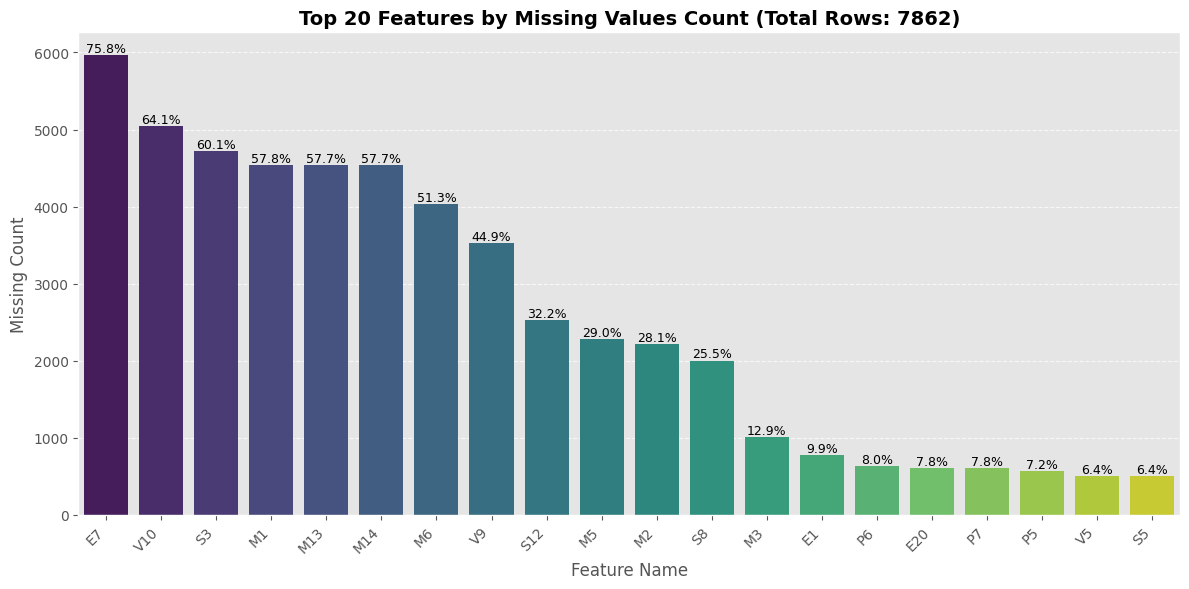


**Missing Data Summary Table (Top 10):**
|     |   Missing_Count |   Missing_Percent |
|:----|----------------:|------------------:|
| E7  |         5963.00 |             75.85 |
| V10 |         5043.00 |             64.14 |
| S3  |         4727.00 |             60.12 |
| M1  |         4541.00 |             57.76 |
| M13 |         4534.00 |             57.67 |
| M14 |         4534.00 |             57.67 |
| M6  |         4037.00 |             51.35 |
| V9  |         3533.00 |             44.94 |
| S12 |         2531.00 |             32.19 |
| M5  |         2277.00 |             28.96 |


In [6]:
missing_df_summary = missing_duplicates_analysis(train_df)

In [7]:
outliers, summary = detect_outliers(train_df, method='iqr')

📊 Outlier Detection Summary:
                               outlier_count  percent_outliers
D6                                      1874             23.84
D5                                      1500             19.08
E4                                      1333             16.95
D8                                      1125             14.31
D9                                      1125             14.31
E12                                     1074             13.66
E6                                       992             12.62
E11                                      979             12.45
E14                                      618              7.86
P6                                       538              6.84
S5                                       482              6.13
E13                                      405              5.15
D3                                       381              4.85
D7                                       363              4.62
P8                        

### CONFIG

In [ ]:
# ADDED: paths point at the prepared, leak-safe split written in the setup cell.
TRAIN_PATH = str(PREPARED / 'train.csv')
LOCAL_GATEWAY_PATH = str(PREPARED)

# ADDED: path for model checkpointsR
_CHECKPOINT_PATH = RESULTS_DIR / 'b_02_checkpoint'
_CHECKPOINT_PATH.mkdir(exist_ok=True)

MODEL_PATH = _CHECKPOINT_PATH / 'lgbm_model.cbm'
FEATURES_PATH = _CHECKPOINT_PATH / 'features.joblib'

TOP_FEATURES_FOR_FE = ['M4', 'V13', 'S5', 'S2', 'D2', 'E19', 'P7', 'P6', 'P3', 'P13', 'P4', 'P5', 'M2', 'V5']
LAG_PERIODS = [1, 3, 5, 7, 14, 20]
ROLLING_WINDOWS = [2, 5, 10, 20, 60]

TARGET = 'market_forward_excess_returns'
COLS_TO_DROP = ['forward_returns', 'risk_free_rate', 'excess_return', 'E7', 'V10', 'S3', 'M1', 'M14']
BEST_C = 0.5

In [9]:
def create_features(df: pd.DataFrame) -> pd.DataFrame:
    
    for col in TOP_FEATURES_FOR_FE:
        if col in df.columns:
            for lag in LAG_PERIODS:
                df[f'{col}_lag_{lag}'] = df[col].shift(lag)
            for window in ROLLING_WINDOWS:
                df[f'{col}_roll_mean_{window}'] = df[col].rolling(window=window, min_periods=1).mean()
                df[f'{col}_roll_std_{window}'] = df[col].rolling(window=window, min_periods=1).std()

    df.ffill(inplace=True)
    for col in df.columns:
        if df[col].isnull().any():
            median_val = df[col].median()
            df[col].fillna(median_val if not np.isnan(median_val) else 0, inplace=True)
            
    return df

In [10]:
warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")
warnings.filterwarnings("ignore", category=RuntimeWarning, module="lightgbm")

if not os.path.exists(MODEL_PATH):
    print("Model not found. Starting training process...")
    
    train_df = pd.read_csv(TRAIN_PATH)
    if 'date_id' not in train_df.columns:
        train_df['date_id'] = train_df.index
    train_df.drop(columns=[col for col in COLS_TO_DROP if col in train_df.columns], inplace=True)

    train_featured = create_features(train_df)
    train_featured.dropna(subset=[TARGET], inplace=True)
    
    FEATURES = [col for col in train_featured.columns if col not in [TARGET, 'date_id']]
    X = train_featured[FEATURES]
    y = train_featured[TARGET]

    def objective(trial):
        params = {
            "objective": "regression",
            "metric": "rmse",
            "n_estimators": trial.suggest_int("n_estimators", 500, 7000),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.07, log=True),
            "max_depth": trial.suggest_int("max_depth", 5, 12),
            "num_leaves": trial.suggest_int("num_leaves", 32, 4012),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "subsample_freq": 1,
            "random_state": 42,
            "verbosity": -1
        }

        tscv = TimeSeriesSplit(n_splits=4)
        scores = []

        for train_index, val_index in tscv.split(X):
            model_opt = LGBMRegressor(**params)
            model_opt.fit(
                X.iloc[train_index],
                y.iloc[train_index],
                eval_set=[(X.iloc[val_index], y.iloc[val_index])],
                eval_metric="rmse",
                callbacks=[
                    early_stopping(200),
                    log_evaluation(-1)
                ]
            )

            preds = model_opt.predict(X.iloc[val_index])
            score, _ = spearmanr(y.iloc[val_index], preds)
            scores.append(score)

        return np.mean(scores)

    if os.getenv('PMLDL_QUICK', '0') == '1':
        best_params = {
            "objective": "regression",
            "metric": "rmse",
            'n_estimators': 6917, 
            'learning_rate': 0.021484317145938295, 
            'max_depth': 8, 
            'num_leaves': 2662, 
            'reg_lambda': 0.0072045470966688365, 
            'reg_alpha': 0.0013718972580079596, 
            'colsample_bytree': 0.7659097201144509, 
            'subsample': 0.7373863632419442,
            "subsample_freq": 1,
            "verbosity": -1
        }
    else:
        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=200, timeout=5400, show_progress_bar=True)
        best_params = study.best_params

    print(f"Best params found: {best_params}")

    final_model = LGBMRegressor(**best_params, random_state=42)
    final_model.fit(X, y)

    joblib.dump(final_model, MODEL_PATH)
    joblib.dump(FEATURES, FEATURES_PATH)

    print("Training complete. Model and features saved.")

else:
    print("Model training skipped: Model file already exists.")


Model not found. Starting training process...


[I 2026-09-16 00:29:02,843] A new study created in memory with name: no-name-33e965d3-9317-49ca-9fd4-68b5b6f188e7


  0%|          | 0/200 [00:00<?, ?it/s]

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[87]	valid_0's rmse: 0.0114078
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[44]	valid_0's rmse: 0.0131367
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[25]	valid_0's rmse: 0.00789739
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[91]	valid_0's rmse: 0.0111581
[I 2026-09-16 00:29:13,544] Trial 0 finished with value: 0.026346834929146405 and parameters: {'n_estimators': 4376, 'learning_rate': 0.010019678750462191, 'max_depth': 8, 'num_leaves': 3609, 'reg_lambda': 0.983710872962063, 'reg_alpha': 0.7029876081995845, 'colsample_bytree': 0.7824264148989677, 'subsample': 0.8583494556938096}. Best is trial 0 with value: 0.026346834929146405.
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	vali

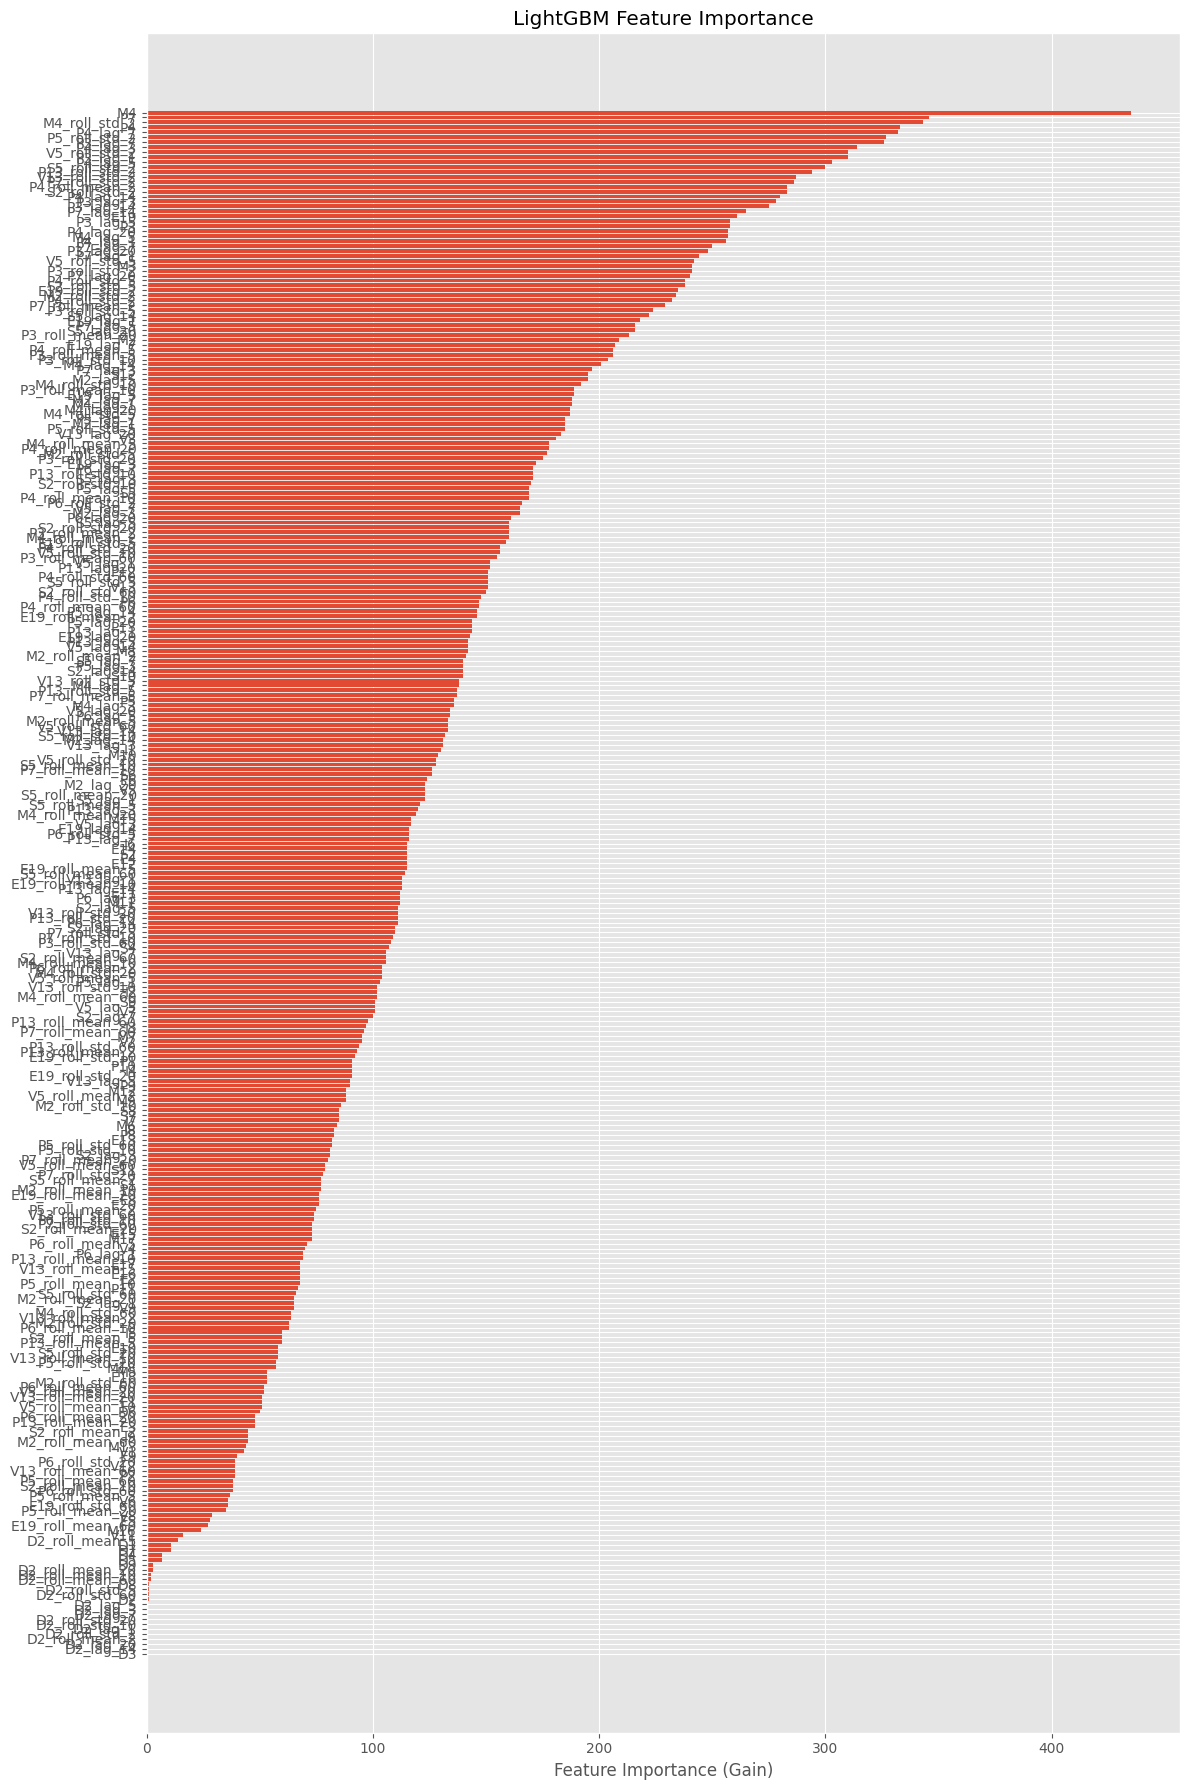

In [11]:
# === Feature Importance Plot ===

importance = final_model.feature_importances_
indices = np.argsort(importance)[::-1]
sorted_features = np.array(FEATURES)[indices]
sorted_importance = importance[indices]

plt.figure(figsize=(12, 18))
plt.barh(sorted_features, sorted_importance)
plt.xlabel("Feature Importance (Gain)")
plt.title("LightGBM Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
print("Loading artifacts for inference...")
try:
    # Load LightGBM model and features
    model = joblib.load(MODEL_PATH)
    MODEL_FEATURES = joblib.load(FEATURES_PATH)
except Exception as e:
    raise RuntimeError(
        f"Could not load model/features. Ensure training was successful. Error: {e}"
    )

print("Initializing prediction history...")
history_df = pd.read_csv(TRAIN_PATH)

cols_to_drop_hist = [
    col for col in COLS_TO_DROP 
    if col in history_df.columns and col != TARGET
]
history_df.drop(columns=cols_to_drop_hist, inplace=True)

if 'date_id' not in history_df.columns:
    history_df['date_id'] = history_df.index

print("Setup complete. Ready for prediction.")

def convert_ret_to_signal(ret_arr: np.ndarray) -> np.ndarray:
    """
    Convert an array of returns to discrete trading signals 0, 1, 2
    """
    q75 = max(0, np.quantile(ret_arr, 0.75))

    signal = np.zeros_like(ret_arr, dtype=int)

    signal[(ret_arr > 0) & (ret_arr <= q75)] = 1

    signal[ret_arr > q75] = 2

    return signal
    
def predict(test_df_pl: pl.DataFrame) -> float:
    global history_df

    # Convert to pandas
    test_df_pd = test_df_pl.to_pandas()

    # Assign next date_id
    if 'date_id' not in test_df_pd.columns:
        last_date_id = history_df['date_id'].max() if not history_df.empty else -1
        test_df_pd['date_id'] = last_date_id + 1

    # Update history
    history_df = pd.concat([history_df, test_df_pd], ignore_index=True)

    # Slice window for feature creation
    slice_size = max(ROLLING_WINDOWS) + max(LAG_PERIODS) + 5
    historical_slice = history_df.tail(slice_size)

    processed_slice = create_features(historical_slice)

    # Select only model feature columns (LightGBM)
    current_features = processed_slice.tail(1)[MODEL_FEATURES]

    # Predict
    prediction = model.predict(current_features)[0]

    signals = convert_ret_to_signal(prediction)
    # # Allocation calculation
    # allocation = np.clip(1 + BEST_C * prediction, 0, 2)

    gc.collect()

    return float(signals)


# ADDED: inference server replaced by the offline replay in the final cell.

Loading artifacts for inference...
Initializing prediction history...
Setup complete. Ready for prediction.


In [15]:
MODEL_NAME = "lgbm_61st"
MODEL_NOTES = "Single LightGBM, lag/rolling features, Optuna on Spearman, discrete signal"

# ===================== ADDED (PMLDL Stage 1) =====================
# Universal results saver. Replays the held-out public block through predict()
# and records the run in results/leaderboard.csv.
# ==================================================================
allocations = replay_public(predict)

metrics = evaluate(
    PUBLIC_Y,
    allocations,               # allocation doubles as the ranking signal here
    weights=allocations,
    forward_returns=PUBLIC_FWD,
    risk_free_rate=PUBLIC_RF,
)
print({k: round(v, 4) for k, v in metrics.items() if isinstance(v, float)})

save_result(
    model=MODEL_NAME, stage="baseline", metrics=metrics,
    split="public", notes=MODEL_NOTES,
)


{'rmse': 0.6318, 'r2': -3752.2073, 'spearman_ic': 0.0478, 'hit_rate': 0.2111, 'modified_sharpe': 0.9972, 'sharpe': 1.1853, 'vol_ratio': 0.7261, 'vol_penalty': 1.0, 'return_penalty': 1.1887, 'bounds_violation': 0.0, 'ann_return': 0.1885, 'ann_volatility': 0.1188, 'max_drawdown': -0.0937, 'benchmark_sharpe': 1.208, 'mean_weight': 0.4, 'weight_turnover': 0.3184}


WindowsPath('C:/Users/bobs/Desktop/Новая папка (3)/PMDL-Project-Market-Prediction/results/leaderboard.csv')

In [18]:
display(compare(split="public"))

,model,stage,split,spearman_ic_mean,spearman_ic,rmse_mean,rmse,modified_sharpe_mean,modified_sharpe,sharpe_mean,sharpe,vol_ratio_mean,vol_ratio
0,hybrid_domain_lgbm,proposed,public,NaN,0.180720,NaN,0.010549,NaN,1.802853,NaN,1.802853,NaN,0.803328
1,improved_ensemble,improved,public,NaN,0.043331,NaN,1.333474,NaN,0.010594,NaN,0.047391,NaN,1.309702
2,elasticnet_leak_safe,baseline,public,NaN,-0.135918,NaN,0.121817,NaN,0.387571,NaN,1.385695,NaN,0.104900
3,online_ensemble_100th,baseline,public,NaN,0.000086,NaN,0.545907,NaN,0.274439,NaN,0.725019,NaN,0.473175
4,lgbm_61st,baseline,public,NaN,0.047796,NaN,0.631812,NaN,0.997153,NaN,1.185332,NaN,0.726148
